<a href="https://colab.research.google.com/github/ostreeshka/DjangoCountriesV1/blob/test/assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")
%matplotlib inline

sns.set(style="darkgrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive') #Импортируем Google Disk в коллаб

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/assignment_1/assignment_1.csv') #Заносим данные из csv файла в DataFrame из Google Disk

In [4]:
data.head() #Проверяем на наличие информации

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
data.shape #Проверяем кол-во информации

(8693, 14)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
data = data.drop(columns=["Name", "PassengerId"]) #Удаляем ненужные данные для обучения машины

In [57]:
if "Cabin" in data.columns: # Разбиваем столбец Cabin на три составляющие (Deck, Num, Side) и удаляем его
    data[["Deck", "Num", "Side"]] = data["Cabin"].str.split("/", expand=True)
    data = data.drop(columns="Cabin")

In [58]:
data=data.replace({True: 1, False: 0}) #Заменяем True на 1 и False на 0

In [59]:
data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side,RoomService_Spent,FoodCourt_Spent,ShoppingMall_Spent,Spa_Spent,VRDeck_Spent
0,0.5,0.0,1.0,0.493671,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,0,0,0,0,0
1,0.0,0.0,1.0,0.303797,0.0,0.091297,0.006517,0.023697,0.363042,0.036667,1.0,5.0,0.0,1.0,1,1,1,1,1
2,0.5,0.0,1.0,0.734177,1.0,0.036689,0.805938,0.000000,0.964023,0.040833,0.0,0.0,0.0,1.0,1,1,0,1,1
3,0.5,0.0,1.0,0.417722,0.0,0.000000,0.554671,0.307109,0.868357,0.154167,0.0,0.0,0.0,1.0,0,1,1,1,1
4,0.0,0.0,1.0,0.202532,0.0,0.223549,0.049964,0.141232,0.374489,0.001667,1.0,5.0,1.0,1.0,1,1,1,1,1


In [60]:
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']: #Заполняем пустые строки нулями
    data[f'{col}_Spent'] = data[col].apply(lambda x: 1 if x > 0 else 0)
    data[col] = data[col].fillna(0)
data = data.dropna()

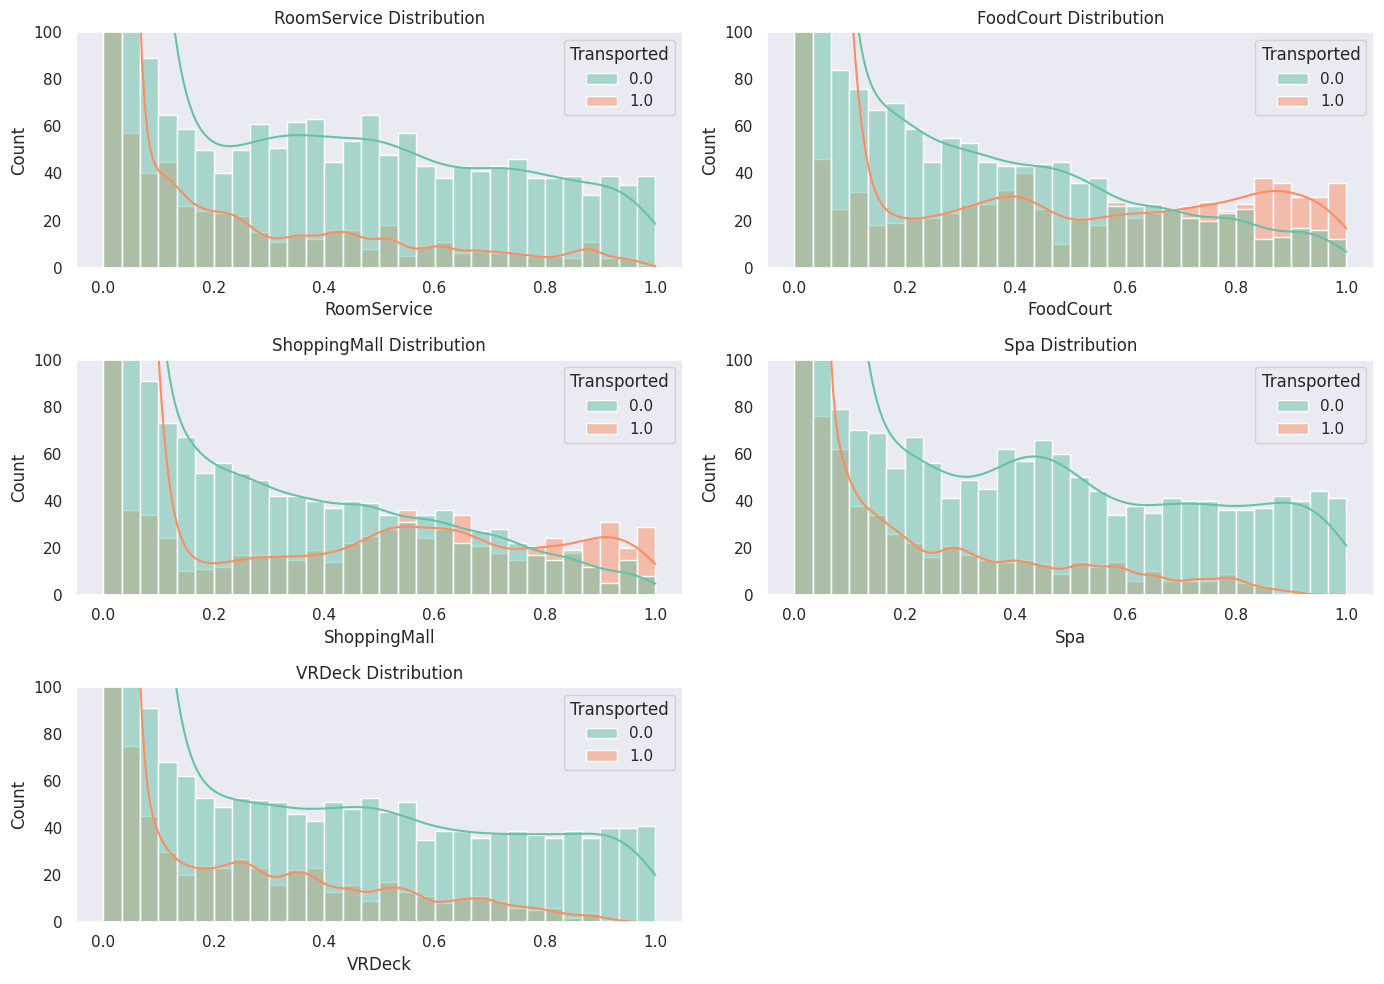

In [61]:
exp_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

plt.figure(figsize=(14,10))
for idx,column in enumerate(exp_cols):
    plt.subplot(3,2,idx+1)
    sns.histplot(x=column, hue="Transported", data=data,bins=30,kde=True,palette="Set2")
    plt.title(f"{column} Distribution")
    plt.ylim(0,100)
    plt.grid()
    plt.tight_layout()

In [13]:
N_data = data.shape[0]
print("Percentage of missing data:")
data.isnull().sum().map(lambda x: f"{x*100/N_data:.2f} %") #Проверяем DataFrame на потерянные данные

Percentage of missing data:


,0
HomePlanet,0.00 %
CryoSleep,0.00 %
Destination,0.00 %
Age,0.00 %
VIP,0.00 %
RoomService,0.00 %
FoodCourt,0.00 %
ShoppingMall,0.00 %
Spa,0.00 %
VRDeck,0.00 %


In [14]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_iris

In [28]:
# Let's highlight the categorical features that need to be encoded
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported',
                        'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck','Deck', 'Num', 'Side' ]

# Creating an Ordinary Encoder
encoder = OrdinalEncoder()

# Applying OrdinalEncoder to categorical features
data[categorical_features] = encoder.fit_transform(data[categorical_features])

In [29]:
scaler = MinMaxScaler()

data.iloc[:, 0:10] = scaler.fit_transform(data.iloc[:, 0:10])

In [30]:
data.sample(10)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side,RoomService_Spent,FoodCourt_Spent,ShoppingMall_Spent,Spa_Spent,VRDeck_Spent
2153,0.5,0.0,0.0,0.341772,0.0,0.000000,0.981897,0.000000,0.061325,0.0000,1.0,2.0,1588.0,0.0,0,1,0,1,0
4892,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,6.0,1613.0,0.0,0,0,0,0,0
289,0.0,0.0,1.0,0.227848,0.0,0.000000,0.001448,0.000000,0.000000,0.0000,0.0,6.0,1171.0,1.0,0,1,0,0,0
2152,0.5,0.0,1.0,0.278481,0.0,0.000000,0.187545,0.002844,0.438267,0.8425,0.0,2.0,1588.0,0.0,0,1,1,1,1
2878,1.0,1.0,1.0,0.265823,0.0,0.000000,0.000000,0.000000,0.000000,0.0000,1.0,3.0,1740.0,0.0,0,0,0,0,0
3540,0.5,1.0,1.0,0.848101,0.0,0.000000,0.000000,0.000000,0.000000,0.0000,1.0,4.0,964.0,1.0,0,0,0,0,0
4011,0.0,0.0,1.0,0.696203,0.0,0.000000,0.165822,0.000948,0.000000,0.3675,1.0,5.0,1564.0,1.0,0,1,1,0,1
6900,1.0,0.0,1.0,0.177215,0.0,0.481229,0.003621,0.253081,0.000000,0.0000,0.0,5.0,556.0,0.0,1,1,1,0,0
1810,0.5,1.0,0.0,0.708861,0.0,0.000000,0.000000,0.000000,0.000000,0.0000,1.0,2.0,1489.0,1.0,0,0,0,0,0
337,0.5,1.0,0.0,0.265823,0.0,0.000000,0.000000,0.000000,0.000000,0.0000,1.0,1.0,112.0,1.0,0,0,0,0,0


In [48]:
X = data.drop(columns='Transported')
y = data['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [49]:
# Стандартизация данных и обучение модели логистической регрессии
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear'))
])

In [50]:
pipeline.fit(X_train, y_train)

# Модельные предсказания и её оценка
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [51]:
print("Точность:", accuracy_score(y_test, y_pred))

Точность: 0.780243000528262


In [52]:
param_grid = {
    # Различные уровни регуляризации
    'C': [0.01, 0.1, 1, 10, 10.44, 10.45, 10.5, 11, 100],
    # Типы регуляризации
    'penalty': ['l1', 'l2'],
    # Используем liblinear, так как он поддерживает l1 и l2
    'solver': ['liblinear']
}

In [53]:
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 10.44, 10.45, 10.5, 11, 100],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='accuracy')

In [55]:
# Лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)

# Оценка производительности модели с оптимальными параметрами
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Точность на тестовой выборке:", accuracy_score(y_test, y_pred))
print("Точность:", accuracy_score(y_test, y_pred))

Лучшие параметры: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Точность на тестовой выборке: 0.7799788695192815
Точность: 0.7799788695192815
